## Chatbot with LangGraph

In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = "Chatbot with LangGraph"

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(api_key=groq_api_key, model="gemma2-9b-it")

## Start building Chatbot using LangGraph

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

# State Graph is for state management
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages 

In [4]:
class State(TypedDict):
    # Messages have the type "list". The "add_messages" function in the annotation
    # defines how this state key is updated.
    # ( in this case, it appends messages to the list, rather than overwriting it )
    
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

In [5]:
graph_builder

In [6]:
def chatbot(state: State):
    return {"messages": llm.invoke(state["messages"])}

In [7]:
graph_builder.add_node("chatbot", chatbot)

In [8]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [9]:
graph = graph_builder.compile()

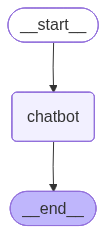

In [10]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

BadRequestError: Error code: 400 - {'error': {'message': 'The model `gemma2-9b-it` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}